In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = 'data_demo/caloGAN_case11_5D_120K.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

data = form_dataset(train=True)
val_data = form_dataset(train=False)
dl = torch.utils.data.DataLoader(data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=256)

In [3]:
from tqdm.auto import tqdm
all_point, all_momentum = [], []
for i in tqdm(val_loader):
    energy = i[0]
    point = i[1][0]
    momentum = i[1][1]
    all_point.append(point)
    all_momentum.append(momentum)
all_point = np.concatenate(all_point)
all_momentum = np.concatenate(all_momentum)

100%|██████████| 235/235 [00:00<00:00, 2319.96it/s]


In [4]:
for k, i in enumerate(val_loader):
    if k == 11:
        energy = i[0]
        point = i[1][0]
        momentum = i[1][1]
        print(i[0].shape)
        print(i[1][0].shape)
        print(i[1][1].shape)
        break

torch.Size([256, 1, 30, 30])
torch.Size([256, 2])
torch.Size([256, 3])


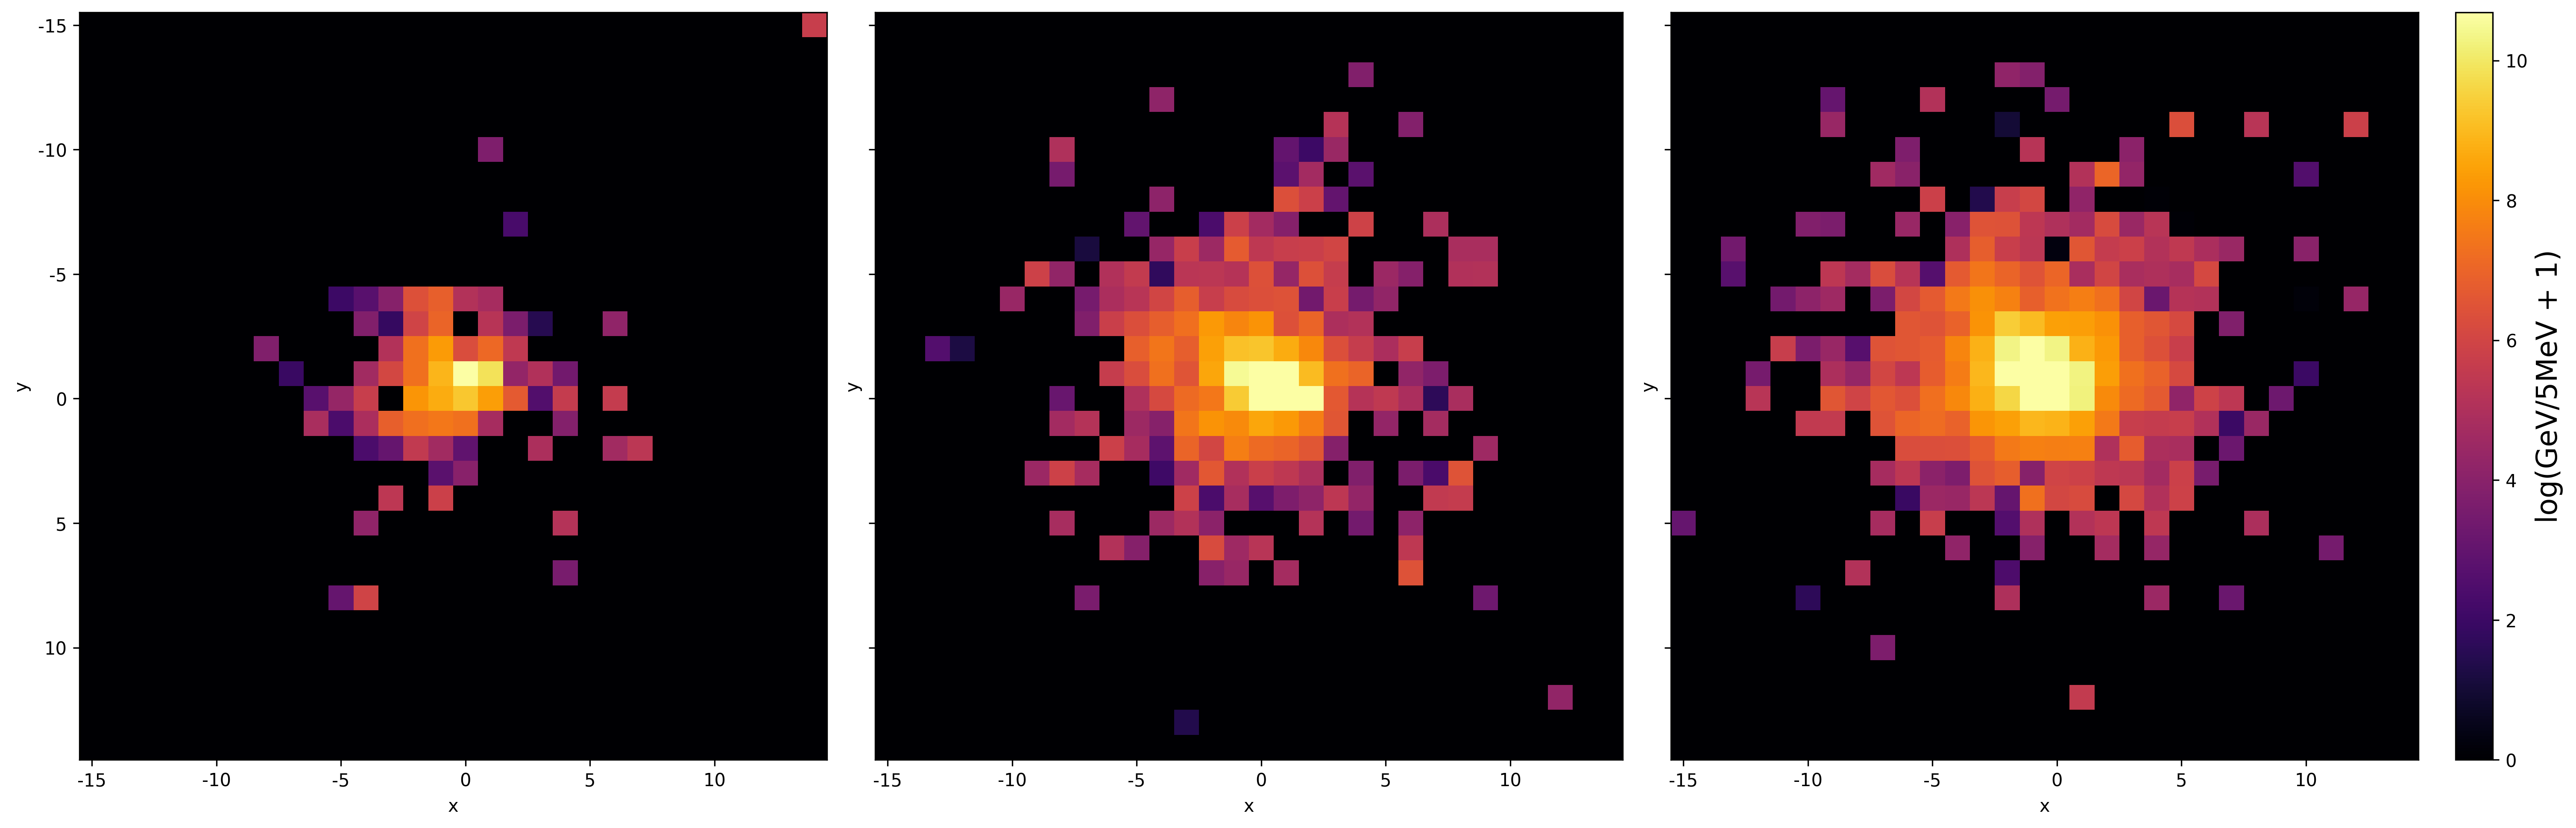

In [5]:
ticks = list(range(-20, 20 + 1, 5))

fig, axs = plt.subplots(1, 3, layout='constrained', sharex=True, sharey=True, dpi=300, figsize=(20, 14))
vmin, vmax = min(energy[0].min(), energy[1].min(), energy[2].min()), max(energy[0].max(), energy[1].max(), energy[2].max())
for i, k in enumerate([1, 3, 5]):
    im = axs[i].imshow(np.transpose(energy[k], (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[i].set_yticklabels(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].set_ylabel('y')
    axs[i].set_xlabel('x')
cbar = fig.colorbar(im, fraction=0.05)
cbar.set_label('log(GeV/5MeV + 1)', size=16)
plt.show()
#fig.savefig('artifacts/real.pdf', bbox_inches = "tight")

In [6]:
device = torch.device("mps")

In [7]:
from diffusion import DiffusionModel

dm = DiffusionModel(100, 16, schedule='linear')
dm.load_state_dict(torch.load('checkpoints/t100_lin_attn_viz.pt', map_location=device))
dm.eval();

In [8]:
16 / 256

0.0625

In [9]:
m, p = momentum.to(device, copy=True), point.to(device, copy=True)

In [13]:
torch.mps.empty_cache()

In [11]:
from experiment import run_experiment, run_evaluation
from hparams import config

run_experiment(config, "data_demo/caloGAN_case11_5D_120K.npz", '.', name='classic diffusion', gamma=False, checkpoint=None)

trainable_params 36018947


KeyboardInterrupt: 

In [6]:
torch.mps.empty_cache()

In [33]:
with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.MPS]) as prof:
    with torch.no_grad():
        samples = dm.sample(momentum, point, truncate=0)
    print(prof.key_averages().table())

AttributeError: type object 'torch._C._profiler.ProfilerActivity' has no attribute 'MPS'

In [14]:
%%timeit
with torch.no_grad():
    samples = dm.sample(momentum, point, truncate=0)

KeyboardInterrupt: 

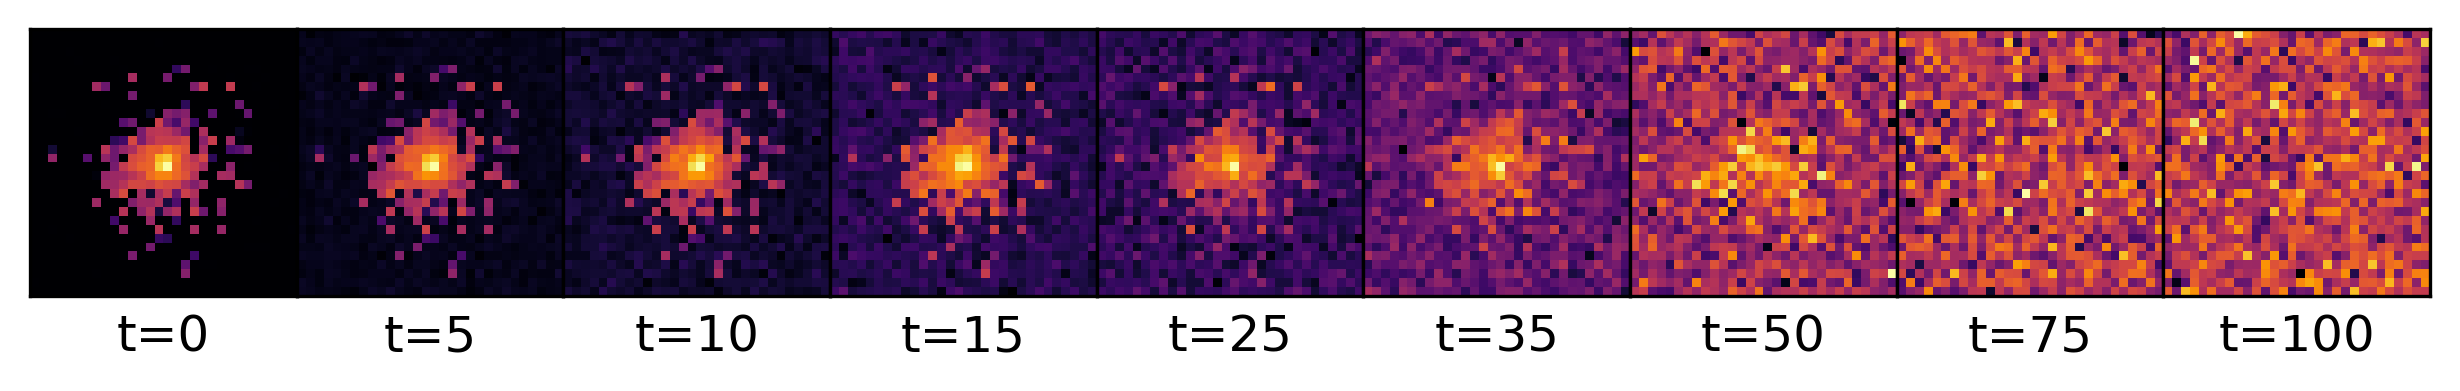

In [35]:
fig, axes = plt.subplots(ncols=9, sharex=True, sharey=True,figsize=(8,4), dpi=300)
fig.subplots_adjust(0,0,1,1,0,0)
for k, i in enumerate([0, 5, 10, 15, 25, 35, 50, 75, 100]):
    x = energy[0]
    eps = torch.randn_like(x)
    x_t = (
        dm.sqrt_alphas_cumprod[i, None, None] * x
        + dm.sqrt_one_minus_alpha_prod[i, None, None] * eps
    ) 
    axes[k].imshow(np.transpose(x_t, (1, 2, 0)), cmap='inferno')
    axes[k].set_title(f't={i}', y=-.3)
    axes[k].set_xticks([])
    axes[k].set_yticks([])
fig.savefig('artifacts/forward.pdf', bbox_inches = "tight")

  0%|          | 0/101 [00:00<?, ?it/s]

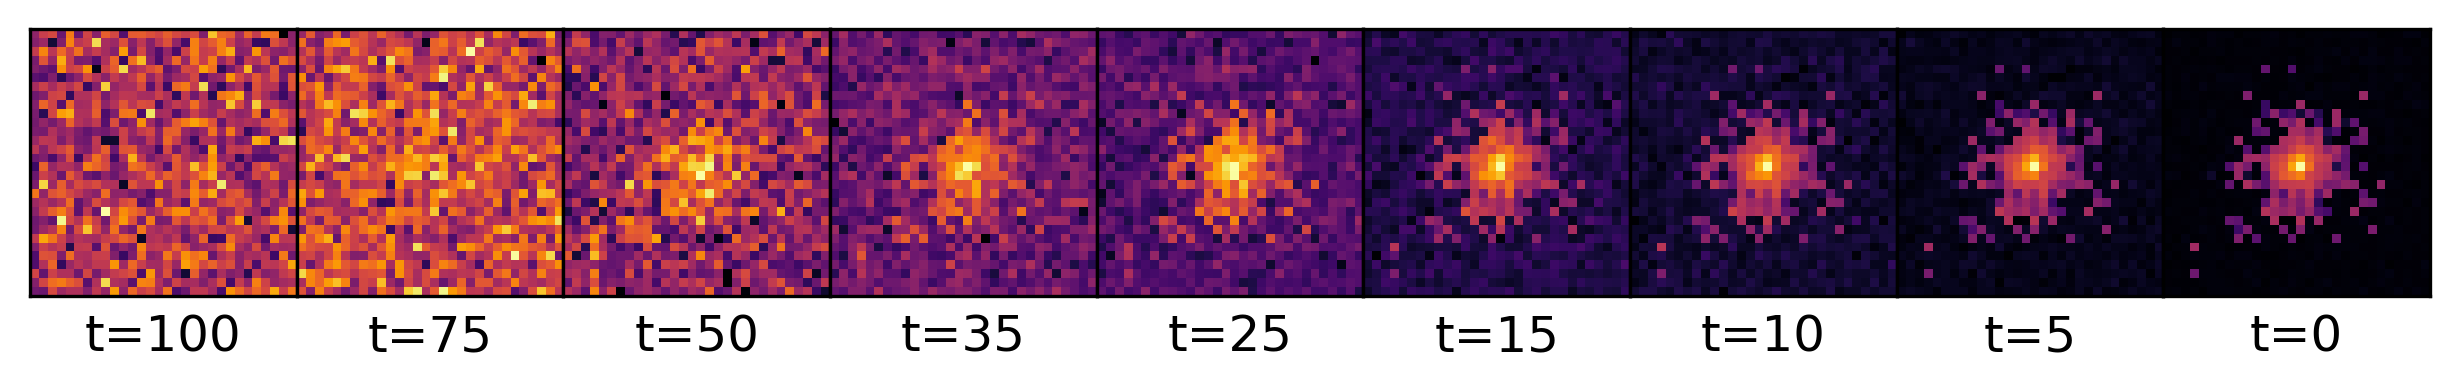

In [36]:
m, p = momentum[0], point[0]
device = m.device
ts = [0, 5, 10, 15, 25, 35, 50, 75, 100]

fig, axes = plt.subplots(ncols=9, sharex=True, sharey=True,figsize=(8,4), dpi=300)
fig.subplots_adjust(0,0,1,1,0,0)
k = 0

x_i = torch.randn(1, 1, 30, 30, device=device)
m, p = m.unsqueeze(0), p.unsqueeze(0)

for i in tqdm(range(dm.num_timesteps, -1, -1), leave=False):
    z = torch.randn(1, 1, 30, 30, device=device) if i > 1 else 0
    eps = dm.eps_model(x_i, m, p, torch.tensor(
        i / dm.num_timesteps).repeat(1, 1).to(device))
    x_i = dm.inv_sqrt_alphas[i] * (
        x_i - eps * dm.one_minus_alpha_over_prod[i]) + dm.sqrt_betas[i] * z
    if i in ts:
        axes[k].imshow(np.transpose(x_i.squeeze(0).detach().numpy(), (1, 2, 0)), cmap='inferno')
        axes[k].set_title(f't={i}', y=-.3)
        axes[k].set_xticks([])
        axes[k].set_yticks([])
        k += 1
fig.savefig('artifacts/reverse.pdf', bbox_inches = "tight")

In [9]:
# from torchview import draw_graph

# model_graph = draw_graph(dm, input_data=(energy, momentum, point), save_graph=True, filename='model')
# model_graph.visual_graph

In [37]:
# from torchsummary import summary

# summary(dm, input_data=[energy, momentum, point], batch_dim=None)

In [19]:
with torch.no_grad():
    samples = dm.sample(momentum, point, truncate=0)

  0%|          | 0/99 [00:00<?, ?it/s]

In [30]:
from data import log1p_inverse_transform, log1p_transform

def compare(energy, samples, idx=0, truncate=None):
    real, sampled = energy[idx].detach().numpy(), samples[idx].detach().numpy()
    if truncate:
        sampled = np.where(sampled >= 0, sampled, np.zeros_like(sampled))
    vmin, vmax = min(real.min(), sampled.min()), max(real.max(), sampled.max())
    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    sum1, sum2 = energy[idx].sum(), samples[idx].sum()
    im1 = axs[0].imshow(np.transpose(real, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0].set(title=f'real {sum1:.2f}')
    im2 = axs[1].imshow(np.transpose(sampled, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1].set(title=f'generated {sum2:.2f}')
    fig.colorbar(im2, fraction=0.05)
    plt.show()

In [13]:
from metrics.calogan_metrics import get_sparsity_level
from data import log1p_inverse_transform
def commm(idx=0, t=0):
    s = log1p_inverse_transform(samples[idx])
    r = log1p_inverse_transform(energy[idx])
    s = np.log10(np.ma.masked_less(s, t))
    r = np.log10(np.ma.masked_less(r, t))
    vmin, vmax = min(r.min(), s.min()), max(r.max(), s.max())
    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    im1 = axs[0].imshow(np.transpose(r, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    im2 = axs[1].imshow(np.transpose(s, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im2, fraction=0.05)
    cbar.set_label('log10(E)', size=12)
    plt.show()
    s = np.where(log1p_inverse_transform(samples[idx]) >= t, samples[idx], torch.zeros_like(samples[idx]))
    print('Non-zero', (energy[idx] > 0).sum().item(), (s > 0).sum().item())
    print('Common', ((energy[idx] > 0) * (s > 0)).sum().item())
    print('Min', energy[idx][energy[idx] > 0].min().item(), s[s > 0].min().item())
    print('Max', energy[idx][energy[idx] > 0].max().item(), s[s > 0].max().item())
    print('Sum', energy[idx][energy[idx] > 0].sum().item(), s[s > 0].sum().item())
    print('Mean', energy[idx][energy[idx] > 0].mean().item(), s[s > 0].mean().item())
    print('Sparsity', np.mean(get_sparsity_level(r)), np.mean(get_sparsity_level(s)))
    return

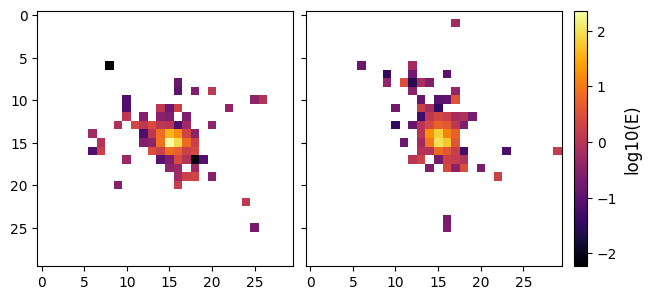

Non-zero 73 69
Common 35
Min 0.0015790946781635284 1.849790096282959
Max 10.734086036682129 9.943341255187988
Sum 348.1861877441406 348.32373046875
Mean 4.769673824310303 5.04817008972168
Sparsity 0.03899999999999999 0.059166666666666666


In [23]:
commm(28, 5e-3)

In [33]:
np.log10(5e-3)

-2.3010299956639813

In [43]:
np.round(np.linspace(np.log10(5e-3)-1e-6, np.log10(s.max()), 8), 1)

array([-2.3, -1.9, -1.5, -1.1, -0.7, -0.3,  0.1,  0.5])

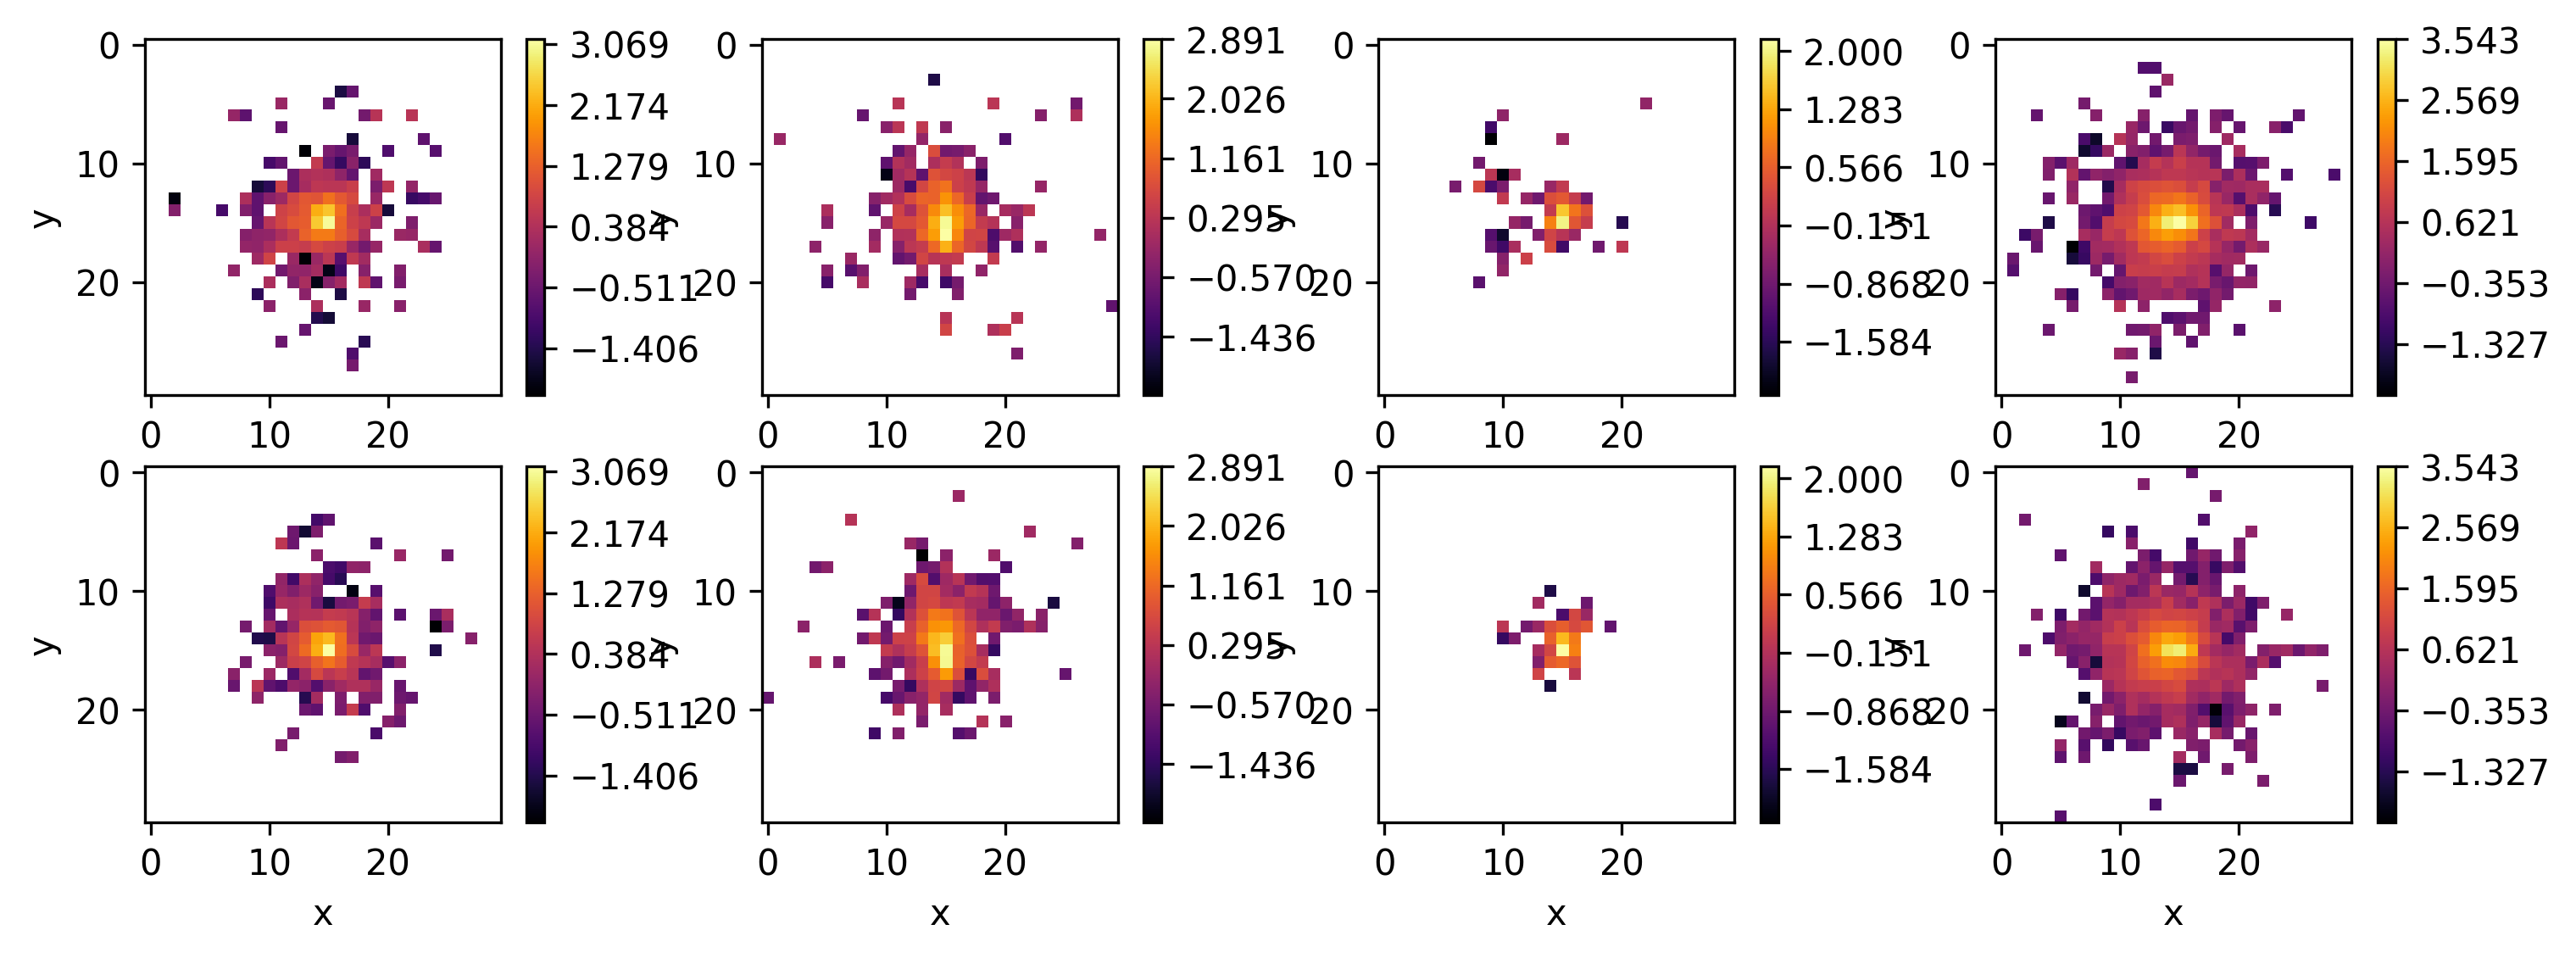

In [42]:
from metrics.calogan_metrics import get_sparsity_level
from data import log1p_inverse_transform
t = 5e-3
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(12,4), dpi=300)
for k, idx in enumerate([0, 3, 10, 11]):
    s = log1p_inverse_transform(samples[idx])
    r = log1p_inverse_transform(energy[idx])
    ticks1 = np.linspace(np.log10(5e-3)-1e-6, np.log10(s.max()), 7)
    ticks2 = np.linspace(np.log10(5e-3)-1e-6, np.log10(r.max()), 7)
    s = np.log10(np.ma.masked_less(s, t))
    r = np.log10(np.ma.masked_less(r, t))
    vmin, vmax = min(r.min(), s.min()), max(r.max(), s.max())
    im1 = axes[0, k].imshow(np.transpose(r, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axes[0, k].set_xlabel('x')
    axes[0, k].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0, k], fraction=0.05, ticks=ticks2)
    im2 = axes[1, k].imshow(np.transpose(s, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axes[1, k].set_xlabel('x')
    axes[1, k].set_ylabel('y')
    plt.colorbar(im2, ax=axes[1, k], fraction=0.05, ticks=ticks2)
    #cbar = fig.colorbar(im2, fraction=0.05)
    #cbar.set_label('log10(E)', size=12)
plt.show()

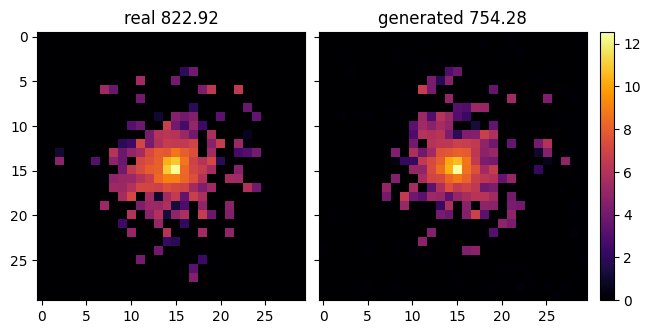

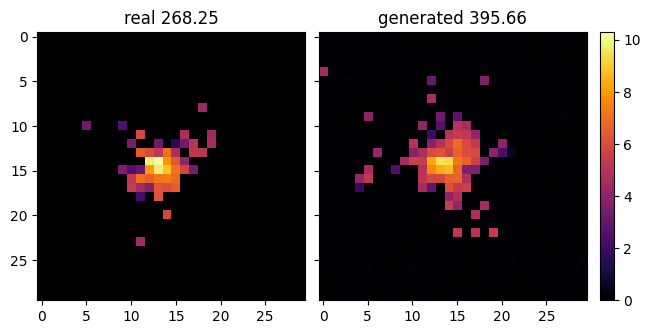

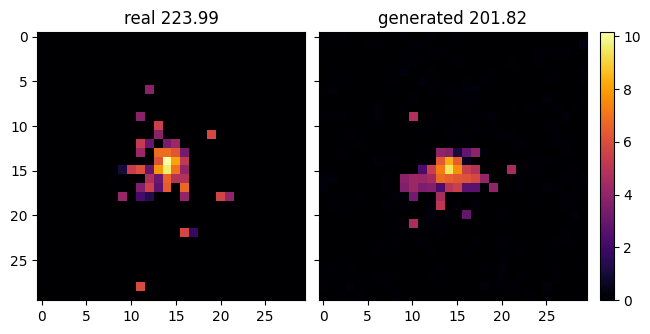

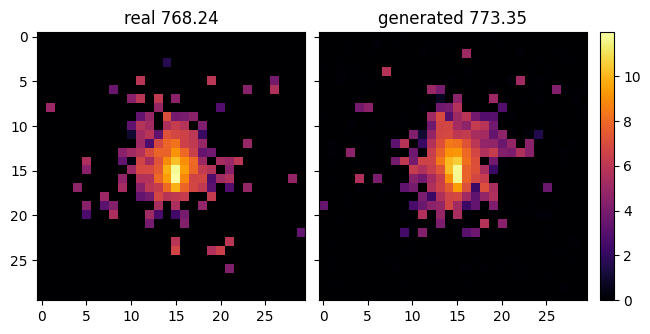

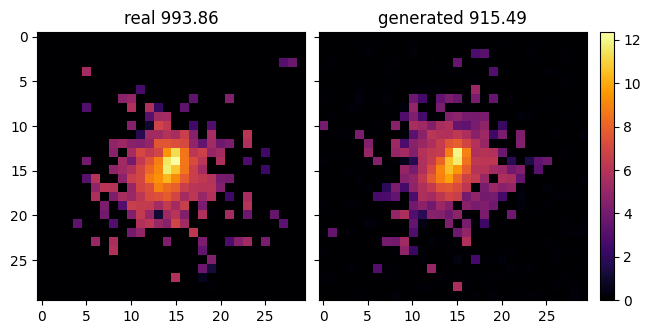

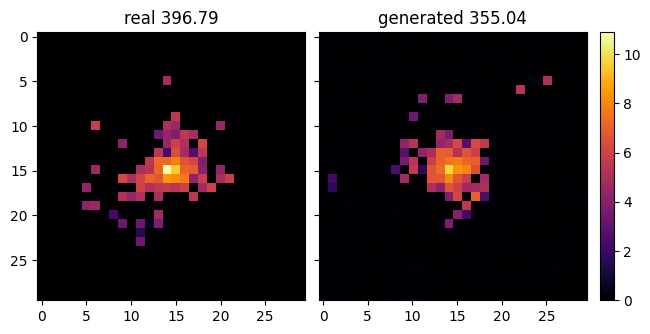

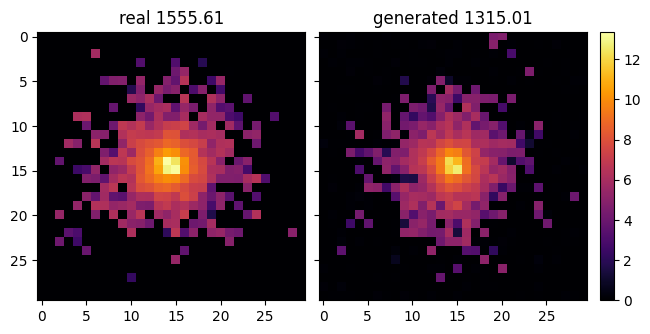

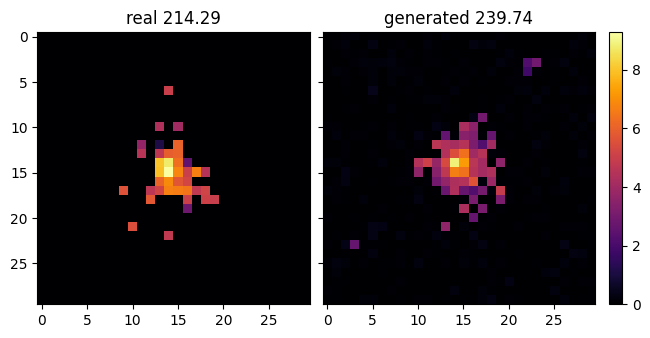

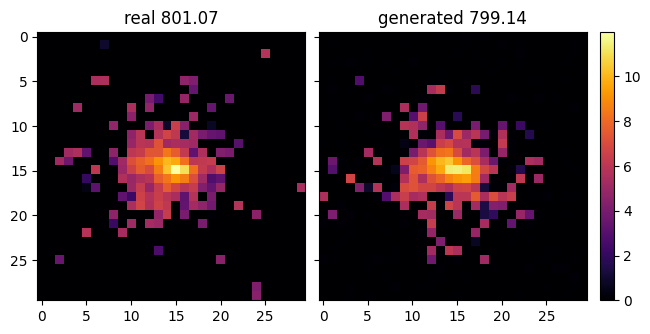

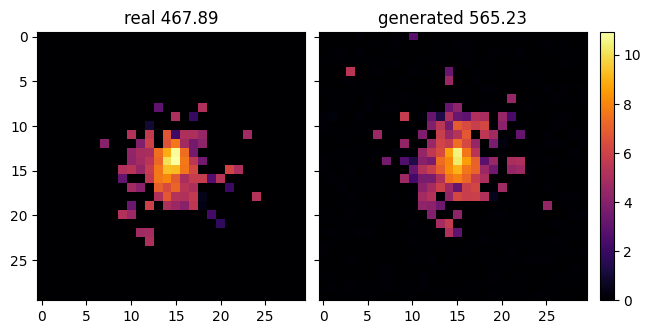

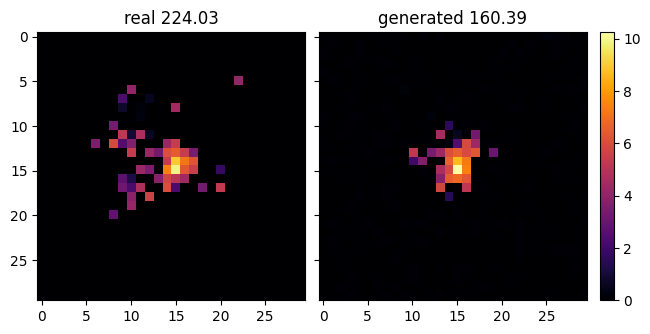

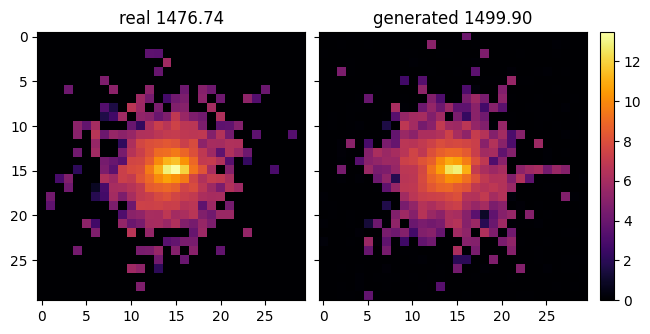

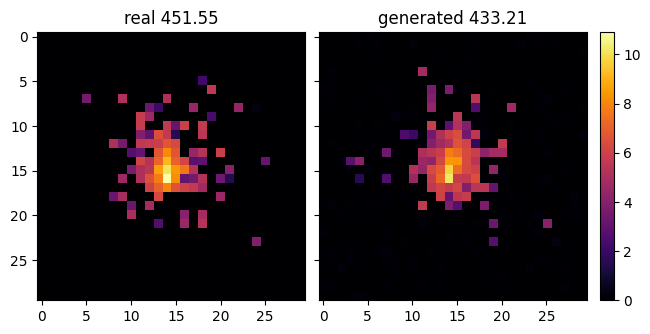

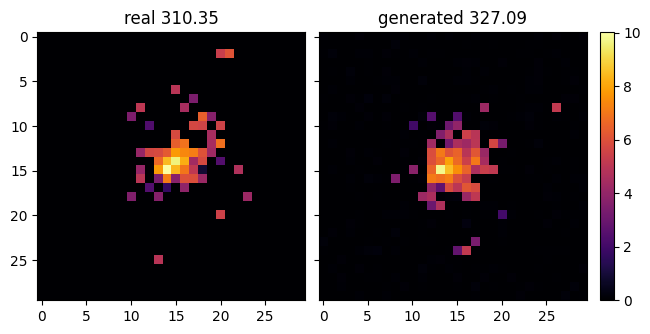

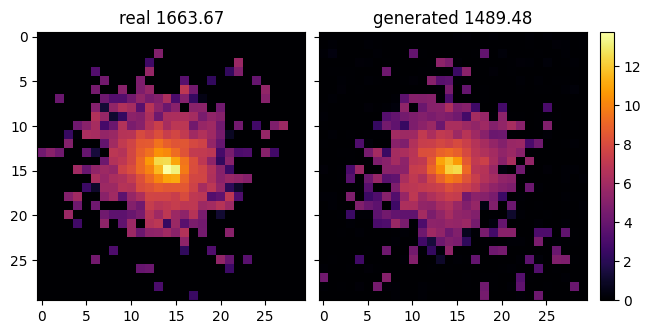

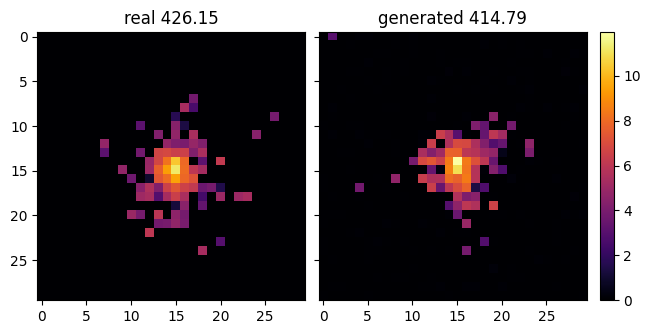

IndexError: index 16 is out of bounds for dimension 0 with size 16

In [31]:
t = 5e-3
for i in range(30):
    compare(energy, samples, idx=i, truncate=t)

In [19]:
def get_s(arr):
    return np.round(np.mean(arr), 3), np.round(np.std(arr), 2)

arr = [1.2501, 1.06863, 1.53146]
get_s(arr)

(1.283, 0.19)

In [161]:
def timestep_to_alpha(timesteps, T, s):
    return np.cos((timesteps / T + 0.008) * np.pi / ((1 + 0.008) * 2)) 

def get_cosine_schedules(num_timesteps: int, s=0.008):

    alphas_cumprod = torch.tensor(timestep_to_alpha(
        np.arange(0, num_timesteps + 1), num_timesteps + 1, s), dtype=torch.float32)
    betas = 1 - alphas_cumprod[1:] / alphas_cumprod[:-1]
    betas = torch.clip(betas, min=1e-8, max=0.999)
    sqrt_betas = torch.sqrt(betas)

    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    inv_sqrt_alphas = 1 / torch.sqrt(alphas)

    sqrt_one_minus_alpha_prod = torch.sqrt(1 - alphas_cumprod)
    one_minus_alpha_over_prod = (1 - alphas) / sqrt_one_minus_alpha_prod
    sigmas = torch.sqrt(
        (1 - alphas_cumprod[:-1]) / (1 - alphas_cumprod[1:]) * (1 - alphas_cumprod[1:] / alphas_cumprod[:-1])
    )

    return {
        "alphas": alphas,
        "inv_sqrt_alphas": inv_sqrt_alphas,
        "sqrt_betas": sqrt_betas,
        "alphas_cumprod": alphas_cumprod,
        "sqrt_alphas_cumprod": sqrt_alphas_cumprod,
        "sqrt_one_minus_alpha_prod": sqrt_one_minus_alpha_prod,
        "one_minus_alpha_over_prod": one_minus_alpha_over_prod,
        "sigmas": sigmas
    }

def get_schedules(beta1: float, beta2: float, num_timesteps: int):
    assert beta1 < beta2 < 1.0, "beta1 and beta2 must be in (0, 1)"

    betas = (beta2 - beta1) * torch.arange(0, num_timesteps +
                                           1, dtype=torch.float32) / num_timesteps + beta1
    sqrt_betas = torch.sqrt(betas)
    alphas = 1 - betas

    alphas_cumprod = torch.cumprod(alphas, dim=0)

    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    inv_sqrt_alphas = 1 / torch.sqrt(alphas)

    sqrt_one_minus_alpha_prod = torch.sqrt(1 - alphas_cumprod)
    one_minus_alpha_over_prod = (1 - alphas) / sqrt_one_minus_alpha_prod
    sigmas = torch.sqrt(
        (1 - alphas_cumprod[:-1]) / (1 - alphas_cumprod[1:]) * (1 - alphas_cumprod[1:] / alphas_cumprod[:-1])
    )

    return {
        "alphas": alphas,
        "inv_sqrt_alphas": inv_sqrt_alphas,
        "sqrt_betas": sqrt_betas,
        "alphas_cumprod": alphas_cumprod,
        "sqrt_alphas_cumprod": sqrt_alphas_cumprod,
        "sqrt_one_minus_alpha_prod": sqrt_one_minus_alpha_prod,
        "one_minus_alpha_over_prod": one_minus_alpha_over_prod,
        "sigmas": sigmas
    }

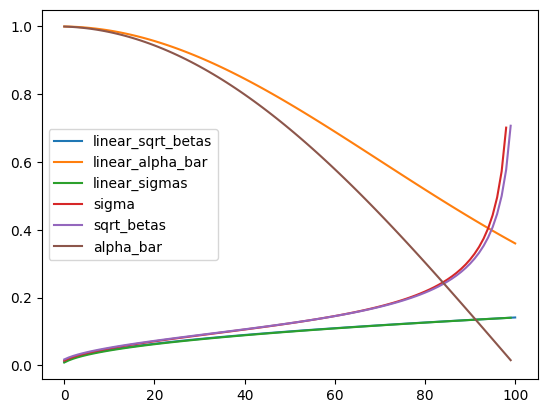

In [163]:
sc = get_cosine_schedules(100, 0.1)
sl = get_schedules(0.0001, 0.02, 100)
plt.figure()
plt.plot(sl['sqrt_betas'], label='linear_sqrt_betas')
plt.plot(sl['alphas_cumprod'], label='linear_alpha_bar')
plt.plot(sl['sigmas'], label='linear_sigmas')
plt.plot(sc['sigmas'], label='sigma')
plt.plot(sc['sqrt_betas'], label='sqrt_betas')
plt.plot(sc['alphas_cumprod'], label='alpha_bar')
plt.legend()
plt.show()